# Klasifikasi Tingkat Obesitas dengan Multi-Layer Perceptron (MLP)
### Tugas Akhir — Mata Kuliah Jaringan Syaraf Tiruan

---

**Dataset:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition  
**Sumber:** UCI Machine Learning Repository  
**Algoritma:** Multi-Layer Perceptron (MLP) dengan Backpropagation  
**Framework:** TensorFlow / Keras  

---


## 1. Pendahuluan

### 1.1 Latar Belakang

Obesitas merupakan salah satu masalah kesehatan global yang semakin mengkhawatirkan. Menurut Organisasi Kesehatan Dunia (WHO), lebih dari 1 miliar orang di dunia mengalami obesitas, dan angka ini terus meningkat setiap tahunnya. Obesitas tidak hanya berdampak pada penampilan fisik, tetapi juga meningkatkan risiko berbagai penyakit kronis seperti diabetes tipe 2, penyakit jantung, hipertensi, dan beberapa jenis kanker.

Deteksi dini tingkat obesitas menjadi sangat penting dalam upaya pencegahan dan penanganan masalah kesehatan ini. Faktor-faktor seperti kebiasaan makan, aktivitas fisik, riwayat keluarga, dan gaya hidup memiliki peran besar dalam menentukan tingkat obesitas seseorang. Dengan memanfaatkan teknik *machine learning*, khususnya Jaringan Syaraf Tiruan (JST), klasifikasi tingkat obesitas dapat dilakukan secara otomatis dan akurat berdasarkan data-data tersebut.

### 1.2 Tujuan Analisis

Tujuan dari analisis ini adalah:
1. Melakukan eksplorasi mendalam terhadap dataset tingkat obesitas
2. Membangun model klasifikasi multi-kelas menggunakan algoritma **Multi-Layer Perceptron (MLP)**
3. Melatih model menggunakan algoritma **Backpropagation**
4. Mengevaluasi performa model dan melakukan *hyperparameter tuning*
5. Menganalisis faktor-faktor yang mempengaruhi tingkat obesitas

### 1.3 Mengapa MLP?

Multi-Layer Perceptron (MLP) dipilih sebagai algoritma utama karena beberapa alasan:

- **Kemampuan klasifikasi multi-kelas**: MLP dapat langsung menangani 7 kelas target dengan menggunakan fungsi aktivasi *Softmax* pada lapisan output
- **Mampu mempelajari pola non-linear**: Dataset ini memiliki relasi kompleks antar fitur yang tidak bersifat linear, sehingga MLP dengan lapisan tersembunyi mampu memodelkan relasi tersebut dengan baik
- **Skalabilitas**: MLP dapat menangani dataset dengan jumlah fitur yang cukup banyak (16 fitur campuran)
- **Fleksibilitas arsitektur**: Jumlah lapisan dan neuron dapat dikonfigurasi untuk mengoptimalkan performa


## 2. Import Library & Load Dataset

In [12]:
# ── Import library standar ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Import preprocessing & evaluasi ─────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# ── Import TensorFlow / Keras ────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Konfigurasi visualisasi ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print(" Library berhasil diimport")
print(f"   TensorFlow  : {tf.__version__}")
print(f"   Keras       : {keras.__version__}")
print(f"   NumPy       : {np.__version__}")
print(f"   Pandas      : {pd.__version__}")


 Library berhasil diimport
   TensorFlow  : 2.19.0
   Keras       : 3.13.2
   NumPy       : 2.0.2
   Pandas      : 2.2.2


In [13]:
# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

print(f" Dataset berhasil dimuat")
print(f"   Dimensi  : {df.shape[0]} baris × {df.shape[1]} kolom")
print()
df.head()


 Dataset berhasil dimuat
   Dimensi  : 2111 baris × 17 kolom



,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [14]:
# ── Informasi dasar dataset ──────────────────────────────────────────────────
print("INFORMASI TIPE DATA & NON-NULL COUNT")
df.info()


INFORMASI TIPE DATA & NON-NULL COUNT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 1

## 3. Data Understanding

### 3.1 Penjelasan Fitur

| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `Gender` | Kategorikal | Jenis kelamin (Male/Female) |
| `Age` | Numerik | Usia dalam tahun |
| `Height` | Numerik | Tinggi badan dalam meter |
| `Weight` | Numerik | Berat badan dalam kilogram |
| `family_history_with_overweight` | Biner | Riwayat keluarga dengan kelebihan berat badan |
| `FAVC` | Biner | Sering mengonsumsi makanan berkalori tinggi |
| `FCVC` | Numerik | Frekuensi konsumsi sayuran dalam setiap makan |
| `NCP` | Numerik | Jumlah makan utama per hari |
| `CAEC` | Kategorikal | Konsumsi makanan di antara waktu makan |
| `SMOKE` | Biner | Kebiasaan merokok |
| `CH2O` | Numerik | Konsumsi air per hari (liter) |
| `SCC` | Biner | Pemantauan kalori harian |
| `FAF` | Numerik | Frekuensi aktivitas fisik per minggu |
| `TUE` | Numerik | Waktu penggunaan perangkat teknologi per hari |
| `CALC` | Kategorikal | Frekuensi konsumsi alkohol |
| `MTRANS` | Kategorikal | Moda transportasi yang digunakan |
| `NObeyesdad` | Target | Tingkat obesitas (7 kelas) |


In [15]:
# ── Cek missing values ────────────────────────────────────────────────────────
print("CEK MISSING VALUES")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values")

# ── Cek duplikasi ─────────────────────────────────────────────────────────────
print()
print("CEK DATA DUPLIKAT")
dup = df.duplicated().sum()
print(f"Jumlah duplikat: {dup}")
if dup > 0:
    df = df.drop_duplicates()
    print(f"Duplikat dihapus. Sisa data: {df.shape[0]} baris")


CEK MISSING VALUES
Tidak ada missing values

CEK DATA DUPLIKAT
Jumlah duplikat: 24
Duplikat dihapus. Sisa data: 2087 baris


In [16]:
# ── Statistik deskriptif fitur numerik ───────────────────────────────────────
print("STATISTIK DESKRIPTIF — FITUR NUMERIK")
df.describe().round(3)


STATISTIK DESKRIPTIF — FITUR NUMERIK


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000,2087.000,2087.000,2087.000,2087.000,2087.000,2087.000,2087.000
mean,24.353,1.703,86.859,2.421,2.701,2.005,1.013,0.663
std,6.369,0.093,26.191,0.535,0.765,0.608,0.853,0.608
min,14.000,1.450,39.000,1.000,1.000,1.000,0.000,0.000
25%,19.916,1.630,66.000,2.000,2.697,1.591,0.125,0.000
50%,22.848,1.702,83.101,2.396,3.000,2.000,1.000,0.631
75%,26.000,1.769,108.016,3.000,3.000,2.466,1.678,1.000
max,61.000,1.980,173.000,3.000,4.000,3.000,3.000,2.000


In [17]:
# ── Distribusi nilai tiap fitur kategorikal ──────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Fitur Kategorikal:", cat_cols)
print()
for col in cat_cols:
    print(f"[{col}]")
    print(df[col].value_counts())
    print()


Fitur Kategorikal: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

[Gender]
Gender
Male      1052
Female    1035
Name: count, dtype: int64

[family_history_with_overweight]
family_history_with_overweight
yes    1722
no      365
Name: count, dtype: int64

[FAVC]
FAVC
yes    1844
no      243
Name: count, dtype: int64

[CAEC]
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

[SMOKE]
SMOKE
no     2043
yes      44
Name: count, dtype: int64

[SCC]
SCC
no     1991
yes      96
Name: count, dtype: int64

[CALC]
CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64

[MTRANS]
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

[NObeyesdad]
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III    

## 4. Exploratory Data Analysis (EDA)

Pada bagian ini dilakukan eksplorasi mendalam terhadap data untuk memahami distribusi, pola, dan hubungan antar variabel sebelum memasuki tahap pemodelan.


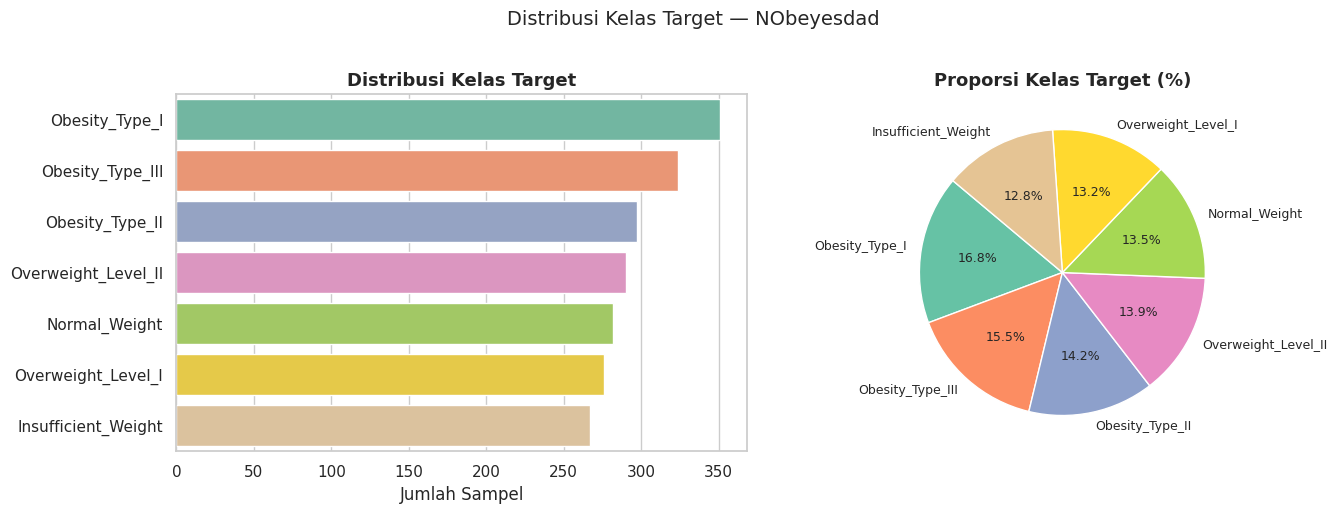


Jumlah sampel per kelas:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


In [18]:
# ── 4.1 Distribusi Kelas Target ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
order = df['NObeyesdad'].value_counts().index
colors = sns.color_palette('Set2', len(order))
sns.countplot(y='NObeyesdad', data=df, order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Sampel')
axes[0].set_ylabel('')

# Pie chart
counts = df['NObeyesdad'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Proporsi Kelas Target (%)', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Kelas Target — NObeyesdad', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nJumlah sampel per kelas:")
print(df['NObeyesdad'].value_counts())


Distribusi kelas target pada dataset ini relatif seimbang (balanced), dengan masing-masing kelas memiliki sekitar 14–16% dari total data. Kondisi ini menguntungkan karena model tidak akan bias ke kelas mayoritas. Kelas `Obesity Type I` memiliki jumlah sampel tertinggi, sementara `Insufficient Weight` memiliki jumlah yang sedikit lebih rendah dibandingkan kelas lain.

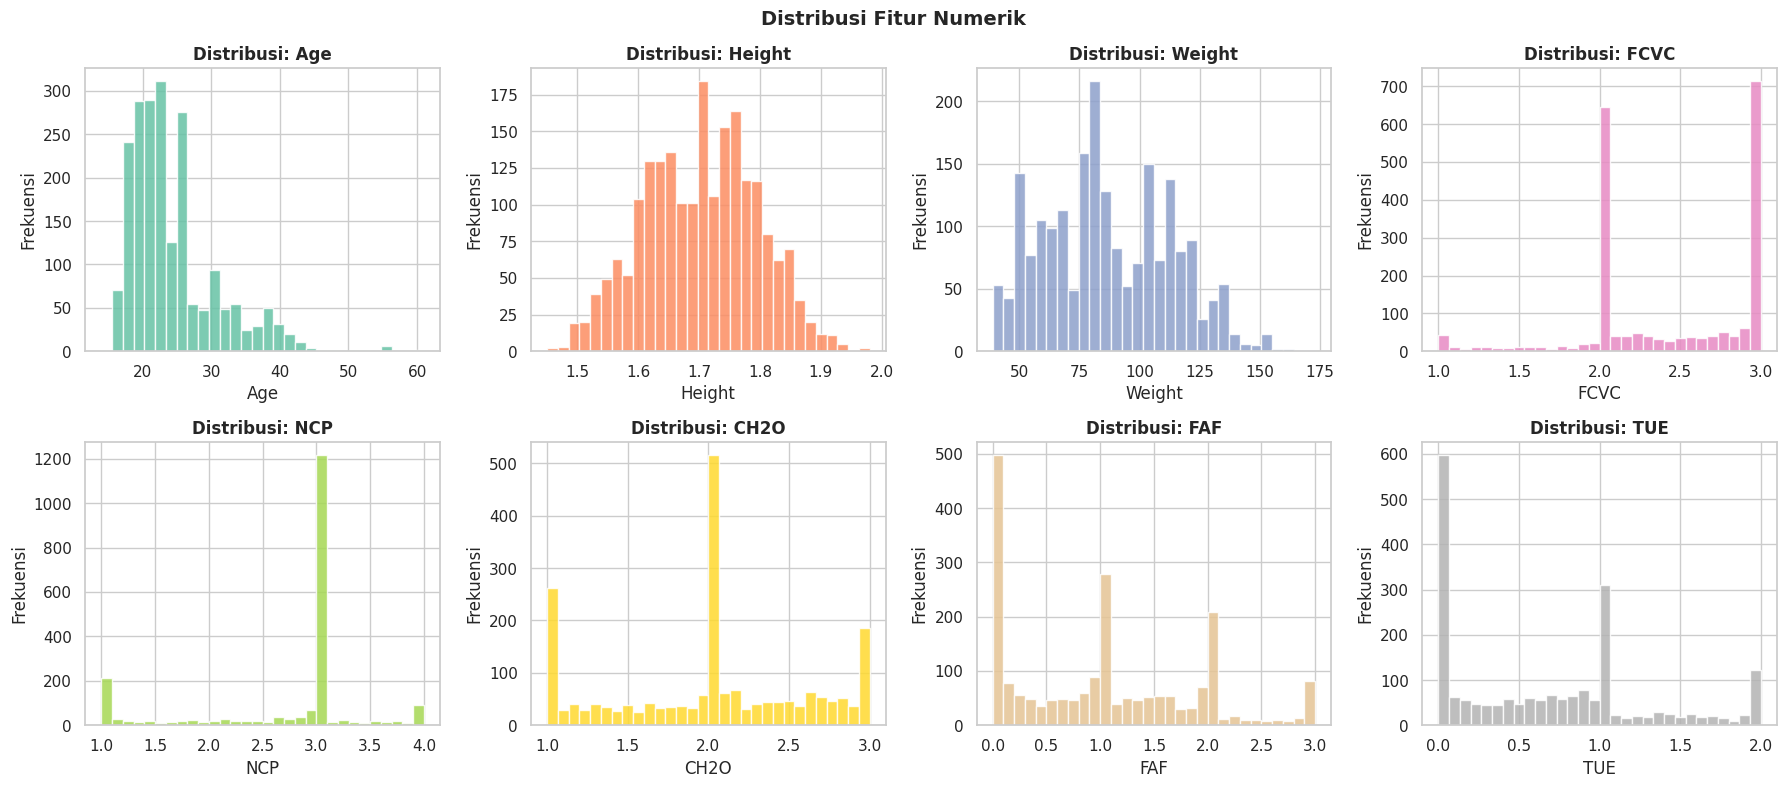

In [19]:
# ── 4.2 Distribusi Fitur Numerik ─────────────────────────────────────────────
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color=sns.color_palette('Set2')[i % 8],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


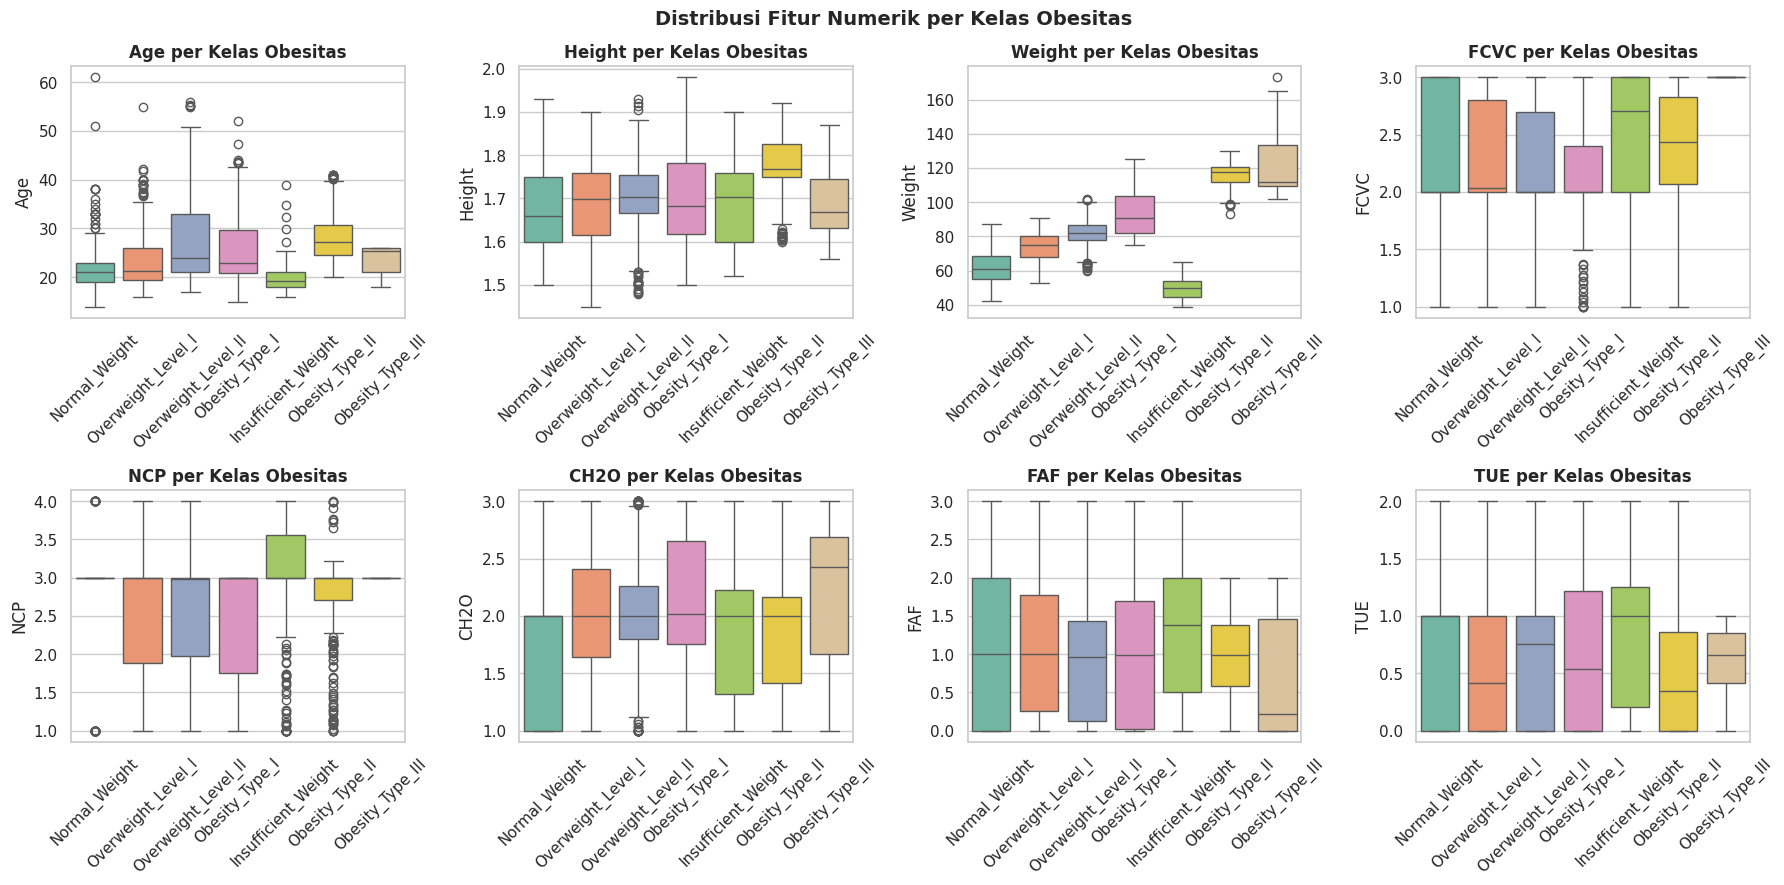

In [20]:
# ── 4.3 Boxplot Fitur Numerik per Kelas Target ───────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='NObeyesdad', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} per Kelas Obesitas', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribusi Fitur Numerik per Kelas Obesitas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Insight:** Fitur `Weight` dan `Height` menunjukkan perbedaan yang sangat signifikan antar kelas obesitas — kelas dengan indeks massa tubuh lebih tinggi (Obesity Type II & III) memiliki median berat badan yang jauh lebih tinggi. Fitur `FAF` (frekuensi aktivitas fisik) cenderung lebih tinggi pada kelas `Insufficient Weight` dan `Normal Weight`, mengindikasikan bahwa aktivitas fisik berkorelasi negatif dengan tingkat obesitas.

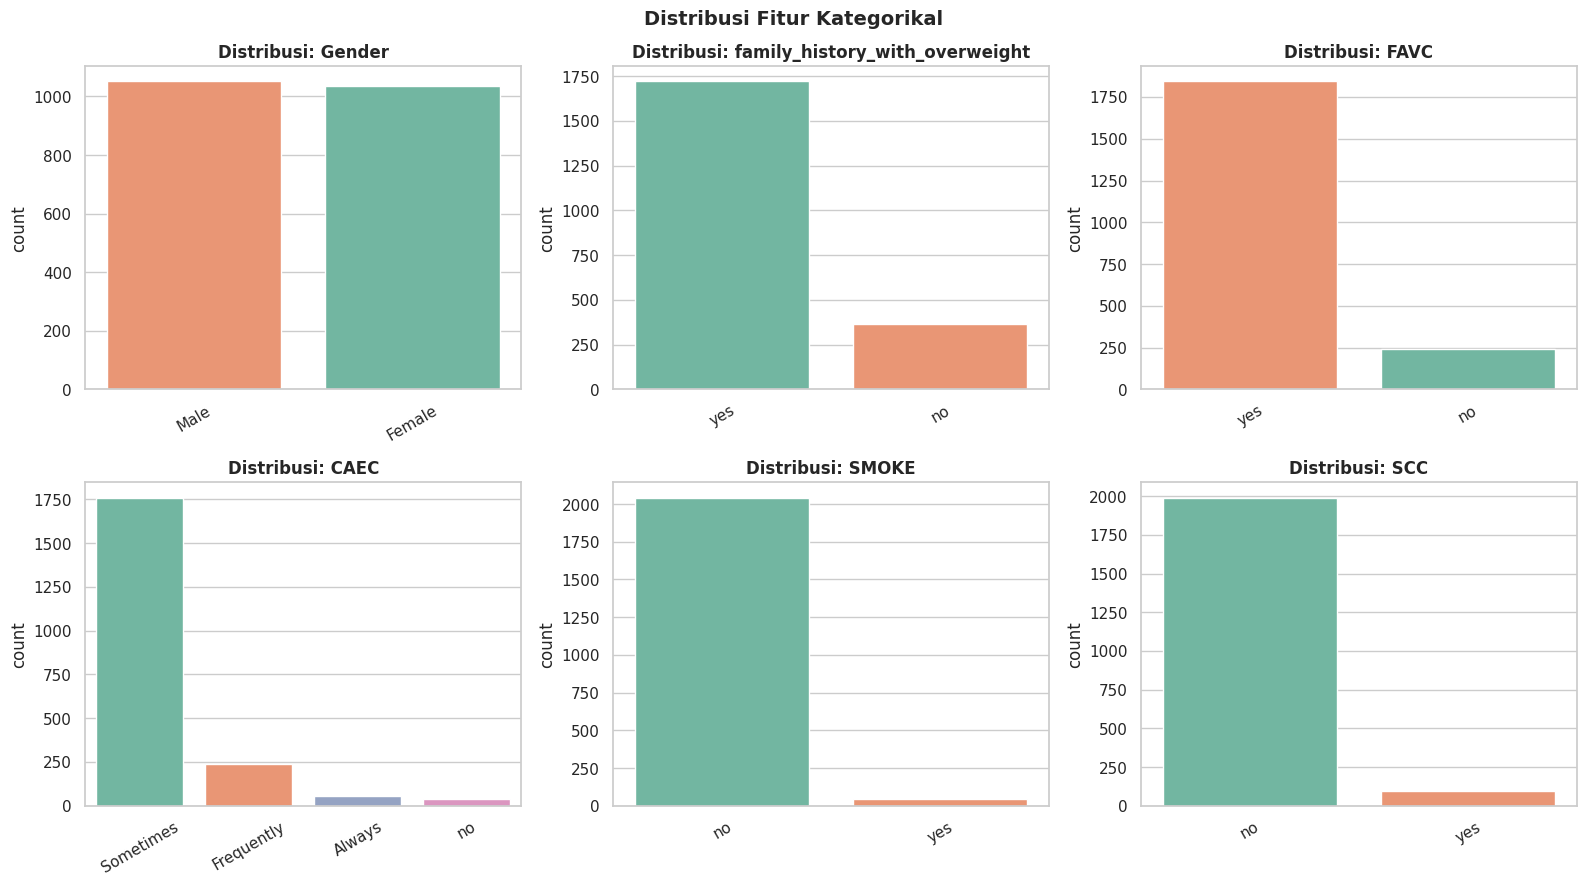

In [21]:
# ── 4.4 Distribusi Fitur Kategorikal ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:-1][:6]):  # kecuali target
    order_cat = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order_cat, palette='Set2',
                  ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


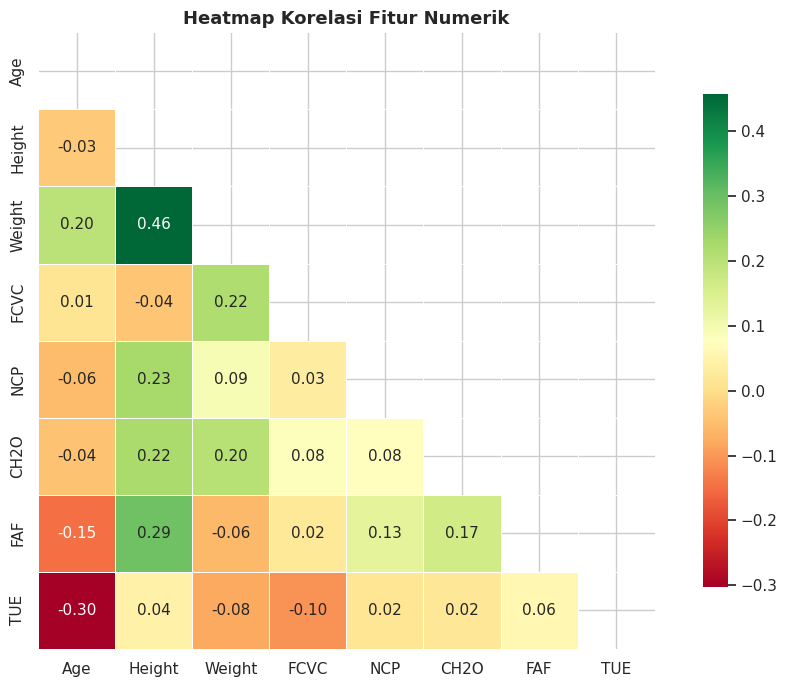

In [22]:
# ── 4.5 Heatmap Korelasi Fitur Numerik ───────────────────────────────────────
plt.figure(figsize=(10, 7))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Heatmap korelasi menunjukkan bahwa tidak terdapat korelasi yang sangat tinggi (multikolinearitas) antar fitur numerik, sehingga semua fitur dapat dipertahankan. Korelasi tertinggi terlihat antara `Weight` dan fitur lainnya, yang wajar mengingat berat badan merupakan komponen utama dalam penentuan tingkat obesitas.

In [23]:
# ── 4.6 Analisis Outlier dengan Metode IQR ───────────────────────────────────
print("ANALISIS OUTLIER (Metode IQR)")
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers
    print(f"  {col:8s} | IQR={IQR:.2f} | Batas=[{lower:.2f}, {upper:.2f}] | Outlier: {n_outliers}")

print()
print("Catatan: Outlier TIDAK dihapus karena merepresentasikan variasi")
print("         alami kondisi fisik manusia yang valid secara medis.")


ANALISIS OUTLIER (Metode IQR)
  Age      | IQR=6.08 | Batas=[10.79, 35.13] | Outlier: 167
  Height   | IQR=0.14 | Batas=[1.42, 1.98] | Outlier: 1
  Weight   | IQR=42.02 | Batas=[2.98, 171.04] | Outlier: 1
  FCVC     | IQR=1.00 | Batas=[0.50, 4.50] | Outlier: 0
  NCP      | IQR=0.30 | Batas=[2.24, 3.45] | Outlier: 577
  CH2O     | IQR=0.88 | Batas=[0.28, 3.78] | Outlier: 0
  FAF      | IQR=1.55 | Batas=[-2.21, 4.01] | Outlier: 0
  TUE      | IQR=1.00 | Batas=[-1.50, 2.50] | Outlier: 0

Catatan: Outlier TIDAK dihapus karena merepresentasikan variasi
         alami kondisi fisik manusia yang valid secara medis.


## 5. Preprocessing

Tahap preprocessing bertujuan untuk mengubah data mentah menjadi format yang dapat diproses oleh algoritma MLP. Beberapa tahapan yang dilakukan meliputi:
1. **Encoding fitur kategorikal** — mengubah nilai teks menjadi angka
2. **Normalisasi fitur numerik** — menyeragamkan skala nilai
3. **Encoding label target** — mengubah kelas target menjadi format *one-hot*
4. **Split data** — membagi data menjadi training dan testing set


In [24]:
# ── Salin dataframe agar data asli tetap terjaga ─────────────────────────────
df_proc = df.copy()

# ── Identifikasi jenis kolom ──────────────────────────────────────────────────
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
ordinal_cols = ['CAEC', 'CALC']
nominal_cols = ['Gender', 'MTRANS']
target_col = 'NObeyesdad'

print("Kolom biner    :", binary_cols)
print("Kolom ordinal  :", ordinal_cols)
print("Kolom nominal  :", nominal_cols)
print("Kolom target   :", target_col)


Kolom biner    : ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
Kolom ordinal  : ['CAEC', 'CALC']
Kolom nominal  : ['Gender', 'MTRANS']
Kolom target   : NObeyesdad


### 5.1 Encoding Fitur Kategorikal

Strategi encoding yang digunakan:
- **Label Encoding** untuk fitur biner (`yes/no`) → menghasilkan 0 dan 1
- **Label Encoding** untuk fitur ordinal (`CAEC`, `CALC`) → mempertahankan urutan relatif
- **One-Hot Encoding** untuk fitur nominal (`Gender`, `MTRANS`) → menghindari asumsi urutan yang tidak ada


In [25]:
# ── Encoding kolom biner (yes/no → 1/0) ─────────────────────────────────────
for col in binary_cols:
    df_proc[col] = df_proc[col].map({'yes': 1, 'no': 0})
    print(f"  [Biner] {col}: {df[col].unique()} → {df_proc[col].unique()}")

# ── Label Encoding untuk kolom ordinal ───────────────────────────────────────
le = LabelEncoder()
for col in ordinal_cols:
    df_proc[col] = le.fit_transform(df_proc[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  [Ordinal] {col}: {mapping}")

# ── One-Hot Encoding untuk kolom nominal ─────────────────────────────────────
df_proc = pd.get_dummies(df_proc, columns=nominal_cols, drop_first=False)
print(f"\n Setelah encoding, jumlah kolom: {df_proc.shape[1]}")
print("Kolom baru:", [c for c in df_proc.columns if c not in df.columns])


  [Biner] family_history_with_overweight: ['yes' 'no'] → [1 0]
  [Biner] FAVC: ['no' 'yes'] → [0 1]
  [Biner] SMOKE: ['no' 'yes'] → [0 1]
  [Biner] SCC: ['no' 'yes'] → [0 1]
  [Ordinal] CAEC: {'Always': np.int64(0), 'Frequently': np.int64(1), 'Sometimes': np.int64(2), 'no': np.int64(3)}
  [Ordinal] CALC: {'Always': np.int64(0), 'Frequently': np.int64(1), 'Sometimes': np.int64(2), 'no': np.int64(3)}

 Setelah encoding, jumlah kolom: 22
Kolom baru: ['Gender_Female', 'Gender_Male', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


### 5.2 Normalisasi Fitur Numerik

**MinMaxScaler** dipilih sebagai metode normalisasi karena:
- Mentransformasi nilai ke rentang [0, 1], yang sesuai dengan fungsi aktivasi ReLU dan Sigmoid
- Dataset ini tidak memiliki outlier ekstrem yang akan mendistorsi hasil scaling
- Mempercepat konvergensi algoritma Backpropagation dengan memastikan semua fitur berada pada skala yang sama


In [26]:
# ── Pisahkan fitur dan target ─────────────────────────────────────────────────
X = df_proc.drop(columns=[target_col])
y = df_proc[target_col]

# ── Normalisasi fitur numerik dengan MinMaxScaler ─────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f" Normalisasi selesai. Shape fitur: {X_scaled.shape}")
print(f"   Range nilai setelah normalisasi: [{X_scaled.values.min():.4f}, {X_scaled.values.max():.4f}]")


 Normalisasi selesai. Shape fitur: (2087, 21)
   Range nilai setelah normalisasi: [0.0000, 1.0000]


In [27]:
# ── Encoding label target ─────────────────────────────────────────────────────
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
class_names = le_target.classes_
print("Mapping kelas target:")
for i, cls in enumerate(class_names):
    print(f"  {i} → {cls}")

# One-hot encoding untuk Keras (categorical crossentropy)
y_onehot = to_categorical(y_encoded, num_classes=len(class_names))
print(f"\nShape y (one-hot): {y_onehot.shape}")


Mapping kelas target:
  0 → Insufficient_Weight
  1 → Normal_Weight
  2 → Obesity_Type_I
  3 → Obesity_Type_II
  4 → Obesity_Type_III
  5 → Overweight_Level_I
  6 → Overweight_Level_II

Shape y (one-hot): (2087, 7)


In [28]:
# ── Train-Test Split (80:20, stratified) ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded        # stratified: menjaga proporsi kelas
)

# Label integer untuk evaluasi sklearn
_, _, y_train_int, y_test_int = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print(f"Split data selesai")
print(f"   Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Testing set  : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Jumlah fitur : {X_train.shape[1]}")


Split data selesai
   Training set : 1669 sampel (80.0%)
   Testing set  : 418 sampel (20.0%)
   Jumlah fitur : 21


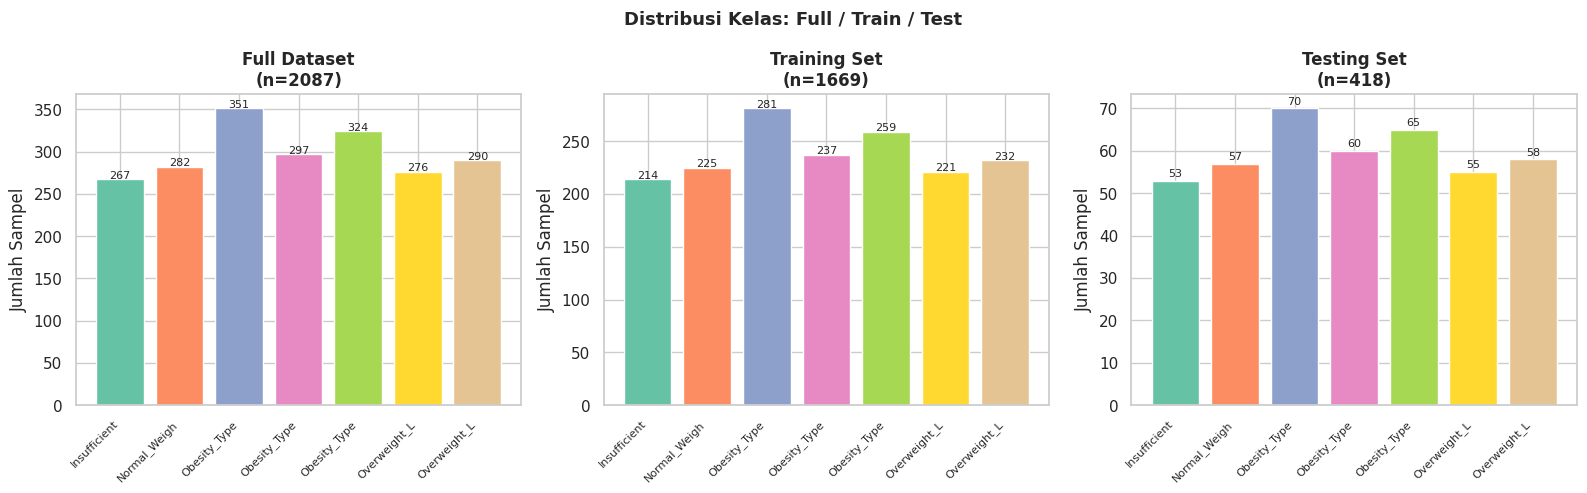

In [29]:
# ── Verifikasi distribusi kelas pada train/test set ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = {
    'Full Dataset': y_encoded,
    'Training Set': y_train_int,
    'Testing Set': y_test_int
}

for ax, (title, y_data) in zip(axes, datasets.items()):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(range(len(counts)), counts.values,
                  color=sns.color_palette('Set2', len(counts)))
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([class_names[i][:12] for i in counts.index],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{title}\n(n={len(y_data)})', fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=8)

plt.suptitle('Distribusi Kelas: Full / Train / Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Landasan Teori MLP & Backpropagation

### 6.1 Arsitektur Multi-Layer Perceptron (MLP)

Multi-Layer Perceptron (MLP) adalah jenis Jaringan Syaraf Tiruan yang terdiri dari tiga jenis lapisan utama:

1. **Input Layer** — menerima vektor fitur input $\mathbf{x} = [x_1, x_2, \ldots, x_n]$
2. **Hidden Layer** — satu atau lebih lapisan tersembunyi yang melakukan transformasi non-linear
3. **Output Layer** — menghasilkan prediksi kelas

```
INPUT LAYER       HIDDEN LAYER 1    HIDDEN LAYER 2    OUTPUT LAYER
                                                      
  x₁  ──────►  h₁₁  ────────►  h₂₁  ───────►  ŷ₁ (Insufficient Weight)
  x₂  ──────►  h₁₂  ────────►  h₂₂  ───────►  ŷ₂ (Normal Weight)
  x₃  ──────►  h₁₃  ────────►  h₂₃  ───────►  ŷ₃ (Overweight I)
   :   ──────►   :             ...   ───────►  ŷ₄ (Overweight II)
  x₂₅ ──────►  h₁ₙ  ────────►  h₂ₘ  ───────►  ŷ₅ (Obesity Type I)
                                               ŷ₆ (Obesity Type II)
                                               ŷ₇ (Obesity Type III)
```

Setiap koneksi antar neuron memiliki **bobot** $w_{ij}$ dan setiap neuron memiliki **bias** $b$.

### 6.2 Fungsi Aktivasi

#### ReLU (Rectified Linear Unit) — Hidden Layers

$$f(z) = \max(0, z)$$

ReLU dipilih karena:
- Komputasi sangat efisien
- Mengatasi masalah *vanishing gradient* yang umum pada fungsi sigmoid/tanh
- Menghasilkan sparsity (banyak aktivasi bernilai 0), memperlancar generalisasi

#### Softmax — Output Layer

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Softmax digunakan pada lapisan output karena mengubah output menjadi distribusi probabilitas yang menjumlah 1, cocok untuk klasifikasi multi-kelas.

### 6.3 Proses Backpropagation

Backpropagation adalah algoritma untuk melatih MLP dengan meminimalkan fungsi loss menggunakan **gradient descent**. Proses berlangsung dalam dua fase:

#### Fase Forward Pass

Output setiap lapisan dihitung sebagai:

$$z^{(l)} = W^{(l)} \cdot a^{(l-1)} + b^{(l)}$$
$$a^{(l)} = f(z^{(l)})$$

#### Fungsi Loss — Categorical Cross-Entropy

$$\mathcal{L} = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)$$

#### Fase Backward Pass (Update Bobot)

Gradien dihitung menggunakan *chain rule*:

$$\delta^{(L)} = \hat{y} - y \quad \text{(error pada output layer)}$$

$$\delta^{(l)} = (W^{(l+1)})^T \cdot \delta^{(l+1)} \odot f'(z^{(l)}) \quad \text{(error propagasi ke lapisan sebelumnya)}$$

Bobot dan bias diperbarui dengan:

$$W^{(l)} \leftarrow W^{(l)} - \eta \cdot \frac{\partial \mathcal{L}}{\partial W^{(l)}}$$

$$b^{(l)} \leftarrow b^{(l)} - \eta \cdot \frac{\partial \mathcal{L}}{\partial b^{(l)}}$$

di mana $\eta$ adalah *learning rate*.

#### Optimizer Adam

Dalam implementasi ini, digunakan **Adam (Adaptive Moment Estimation)** sebagai optimizer, yang merupakan pengembangan dari SGD:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{W} = W - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Adam dipilih karena adaptif terhadap learning rate tiap parameter dan umumnya lebih cepat konvergen.


## 7. Pemodelan MLP

### 7.1 Arsitektur Model Dasar

Model MLP dibangun dengan konfigurasi berikut:
- **Input:** 25 fitur (setelah encoding dan normalisasi)
- **Hidden Layer 1:** 128 neuron, aktivasi ReLU + Dropout 30%
- **Hidden Layer 2:** 64 neuron, aktivasi ReLU + Dropout 20%
- **Output Layer:** 7 neuron, aktivasi Softmax


In [30]:
# ── Bangun model MLP ─────────────────────────────────────────────────────────
def build_model(n_input, n_output, hidden_units=[128, 64],
                dropout_rates=[0.3, 0.2], lr=0.001):
    """
    Membangun arsitektur MLP dengan Keras Sequential API.

    Parameters
    ----------
    n_input      : jumlah fitur input
    n_output     : jumlah kelas target
    hidden_units : list jumlah neuron per hidden layer
    dropout_rates: list dropout rate per hidden layer
    lr           : learning rate optimizer Adam
    """
    model = keras.Sequential(name='MLP_Obesity')

    # Input layer + Hidden layer pertama
    model.add(layers.Dense(hidden_units[0], activation='relu',
                           input_shape=(n_input,),
                           kernel_initializer='he_normal',
                           name='hidden_1'))
    model.add(layers.Dropout(dropout_rates[0], name='dropout_1'))

    # Hidden layer selanjutnya
    for i, (units, dr) in enumerate(zip(hidden_units[1:], dropout_rates[1:]), start=2):
        model.add(layers.Dense(units, activation='relu',
                               kernel_initializer='he_normal',
                               name=f'hidden_{i}'))
        model.add(layers.Dropout(dr, name=f'dropout_{i}'))

    # Output layer — Softmax untuk multi-class
    model.add(layers.Dense(n_output, activation='softmax', name='output'))

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

N_INPUT  = X_train.shape[1]
N_OUTPUT = len(class_names)

model = build_model(N_INPUT, N_OUTPUT)
model.summary()


Model: "MLP_Obesity"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,527 (45.03 KB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# ── Callback: EarlyStopping & ModelCheckpoint ─────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',      # pantau validation loss
        patience=15,             # berhenti jika tidak ada perbaikan selama 15 epoch
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

# ── Training model ─────────────────────────────────────────────────────────────
print("Memulai pelatihan model...")
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,      # 20% dari training untuk validasi
    callbacks=callbacks,
    verbose=1
)

print(f"\n Pelatihan selesai pada epoch ke-{len(history.history['loss'])}")


Memulai pelatihan model...
Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.1805 - loss: 2.0676 - val_accuracy: 0.3713 - val_loss: 1.7766
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3146 - loss: 1.7731 - val_accuracy: 0.3832 - val_loss: 1.5807
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3880 - loss: 1.5923 - val_accuracy: 0.4701 - val_loss: 1.3852
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4412 - loss: 1.4431 - val_accuracy: 0.5299 - val_loss: 1.2608
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4944 - loss: 1.3034 - val_accuracy: 0.5509 - val_loss: 1.1516
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5228 - loss: 1.2225 - val_accuracy: 0.5689 - val_loss: 1.0854
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5438 - loss: 1.1664 - val_accuracy: 0.5778 - val_loss: 1.0418
Epoch 8/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5610 - loss: 1.111

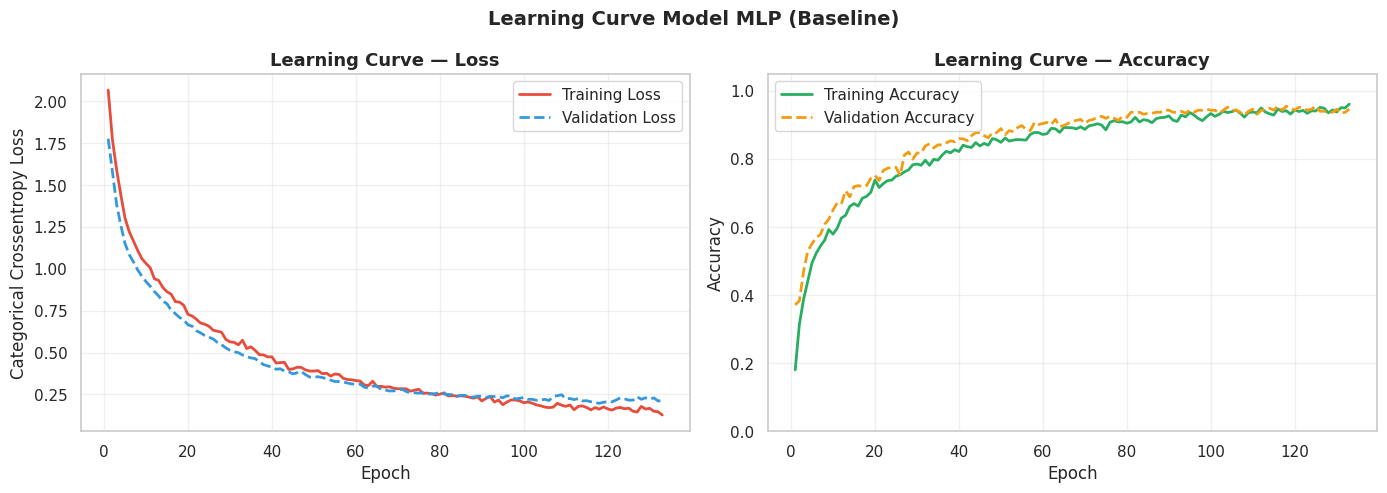

Loss training terbaik  : 0.1270
Loss validasi terbaik  : 0.1969
Akurasi training       : 0.9610
Akurasi validasi       : 0.9551


In [32]:
# ── Plot Learning Curve ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

# Plot Loss
axes[0].plot(epochs_range, history.history['loss'], label='Training Loss',
             color='#E74C3C', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'], label='Validation Loss',
             color='#3498DB', linewidth=2, linestyle='--')
axes[0].set_title('Learning Curve — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(epochs_range, history.history['accuracy'], label='Training Accuracy',
             color='#27AE60', linewidth=2)
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy',
             color='#F39C12', linewidth=2, linestyle='--')
axes[1].set_title('Learning Curve — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.suptitle('Learning Curve Model MLP (Baseline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Loss training terbaik  : {min(history.history['loss']):.4f}")
print(f"Loss validasi terbaik  : {min(history.history['val_loss']):.4f}")
print(f"Akurasi training       : {max(history.history['accuracy']):.4f}")
print(f"Akurasi validasi       : {max(history.history['val_accuracy']):.4f}")


## 8. Evaluasi Model

In [33]:
# ── Prediksi pada data test ───────────────────────────────────────────────────
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_int  = np.argmax(y_pred_prob, axis=1)

# ── Accuracy Score ────────────────────────────────────────────────────────────
acc = accuracy_score(y_test_int, y_pred_int)
print(f"  AKURASI MODEL (Baseline): {acc*100:.2f}%")


  AKURASI MODEL (Baseline): 91.39%


In [34]:
# ── Classification Report ─────────────────────────────────────────────────────
print("CLASSIFICATION REPORT")
print(classification_report(y_test_int, y_pred_int, target_names=class_names))


CLASSIFICATION REPORT
                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.94      0.90        53
      Normal_Weight       0.82      0.72      0.77        57
     Obesity_Type_I       0.96      1.00      0.98        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.79      0.89      0.84        55
Overweight_Level_II       0.96      0.86      0.91        58

           accuracy                           0.91       418
          macro avg       0.91      0.91      0.91       418
       weighted avg       0.92      0.91      0.91       418



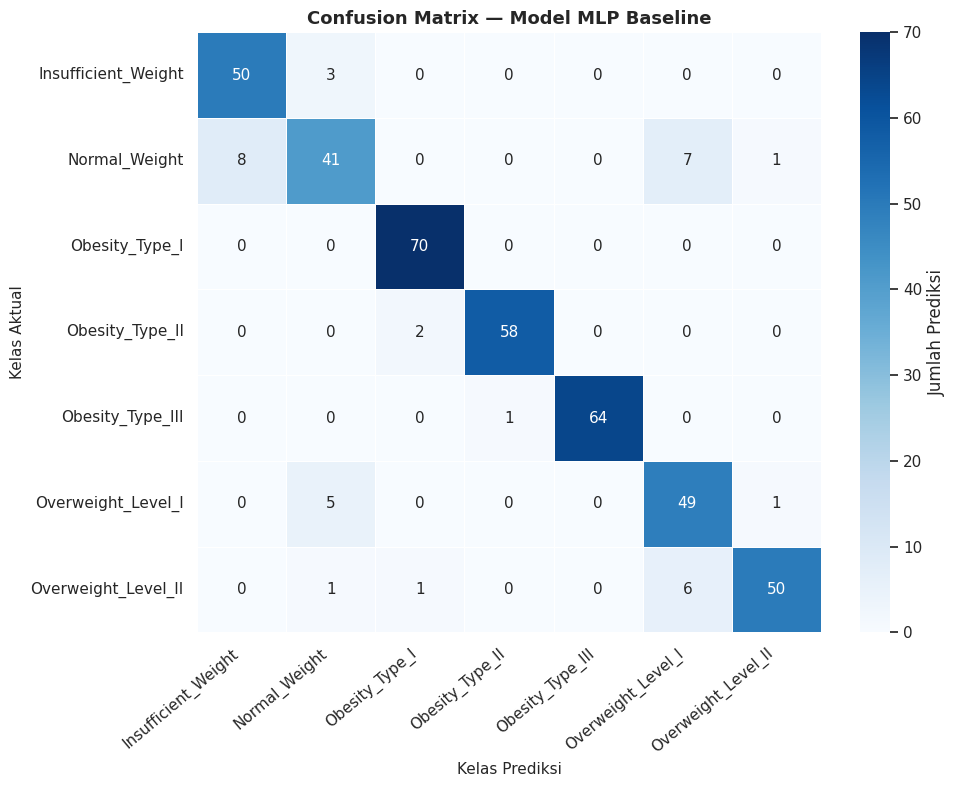

In [35]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': 'Jumlah Prediksi'})
plt.title('Confusion Matrix — Model MLP Baseline', fontsize=13, fontweight='bold')
plt.ylabel('Kelas Aktual', fontsize=11)
plt.xlabel('Kelas Prediksi', fontsize=11)
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Analisis Confusion Matrix:**

Confusion matrix menunjukkan performa model per kelas. Diagonal utama (kiri atas ke kanan bawah) merepresentasikan prediksi yang benar. Perhatikan kelas mana yang sering salah diprediksi (nilai besar di luar diagonal). Secara umum, kelas-kelas yang bertetangga (misalnya `Overweight Level I` dan `Overweight Level II`) cenderung lebih mudah tertukar karena perbedaan karakteristiknya yang tipis. Kelas `Obesity Type III` dan `Insufficient Weight` biasanya lebih mudah diprediksi karena memiliki fitur yang lebih ekstrem dan distinktif.


## 9. Hyperparameter Tuning

Untuk menemukan konfigurasi model terbaik, dilakukan eksperimen dengan **4 variasi konfigurasi** yang memvariasikan jumlah hidden layer, jumlah neuron, learning rate, dan dropout rate.


In [36]:
# ── Definisi eksperimen ───────────────────────────────────────────────────────
experiments = [
    {
        'nama'        : 'Config A (Baseline)',
        'hidden_units': [128, 64],
        'dropout'     : [0.3, 0.2],
        'lr'          : 0.001,
    },
    {
        'nama'        : 'Config B (Deeper)',
        'hidden_units': [256, 128, 64],
        'dropout'     : [0.3, 0.3, 0.2],
        'lr'          : 0.001,
    },
    {
        'nama'        : 'Config C (Wider)',
        'hidden_units': [512, 256],
        'dropout'     : [0.4, 0.3],
        'lr'          : 0.001,
    },
    {
        'nama'        : 'Config D (Lower LR)',
        'hidden_units': [256, 128, 64],
        'dropout'     : [0.3, 0.3, 0.2],
        'lr'          : 0.0005,
    },
]

results = []
histories = {}

for cfg in experiments:
    print(f"\n▶ Melatih {cfg['nama']} ...")
    m = build_model(N_INPUT, N_OUTPUT,
                    hidden_units=cfg['hidden_units'],
                    dropout_rates=cfg['dropout'],
                    lr=cfg['lr'])

    cb = [EarlyStopping(monitor='val_loss', patience=15,
                        restore_best_weights=True, verbose=0)]

    hist = m.fit(X_train, y_train,
                 epochs=200, batch_size=32,
                 validation_split=0.2,
                 callbacks=cb, verbose=0)

    # Evaluasi pada test set
    y_pred_cfg = np.argmax(m.predict(X_test, verbose=0), axis=1)
    acc_cfg    = accuracy_score(y_test_int, y_pred_cfg)

    results.append({
        'Konfigurasi'   : cfg['nama'],
        'Hidden Layers' : len(cfg['hidden_units']),
        'Neurons'       : str(cfg['hidden_units']),
        'Learning Rate' : cfg['lr'],
        'Epochs (Stop)' : len(hist.history['loss']),
        'Val Accuracy'  : round(max(hist.history['val_accuracy']), 4),
        'Test Accuracy' : round(acc_cfg, 4),
    })
    histories[cfg['nama']] = hist
    print(f" Selesai — Test Accuracy: {acc_cfg*100:.2f}%")

print("\n Semua eksperimen selesai")



▶ Melatih Config A (Baseline) ...
 Selesai — Test Accuracy: 91.15%

▶ Melatih Config B (Deeper) ...
 Selesai — Test Accuracy: 90.19%

▶ Melatih Config C (Wider) ...
 Selesai — Test Accuracy: 89.23%

▶ Melatih Config D (Lower LR) ...
 Selesai — Test Accuracy: 88.04%

 Semua eksperimen selesai


In [37]:
# ── Tabel Perbandingan Hasil ─────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print("TABEL PERBANDINGAN KONFIGURASI HYPERPARAMETER")
print(results_df.to_string(index=False))
print()

# Highlight model terbaik
best_idx = results_df['Test Accuracy'].idxmax()
best_cfg  = results_df.loc[best_idx, 'Konfigurasi']
best_acc  = results_df.loc[best_idx, 'Test Accuracy']
print(f" Model terbaik: {best_cfg} dengan Test Accuracy = {best_acc*100:.2f}%")


TABEL PERBANDINGAN KONFIGURASI HYPERPARAMETER
        Konfigurasi  Hidden Layers        Neurons  Learning Rate  Epochs (Stop)  Val Accuracy  Test Accuracy
Config A (Baseline)              2      [128, 64]         0.0010            150        0.9491         0.9115
  Config B (Deeper)              3 [256, 128, 64]         0.0010             83        0.9311         0.9019
   Config C (Wider)              2     [512, 256]         0.0010             57        0.9192         0.8923
Config D (Lower LR)              3 [256, 128, 64]         0.0005            117        0.9192         0.8804

 Model terbaik: Config A (Baseline) dengan Test Accuracy = 91.15%


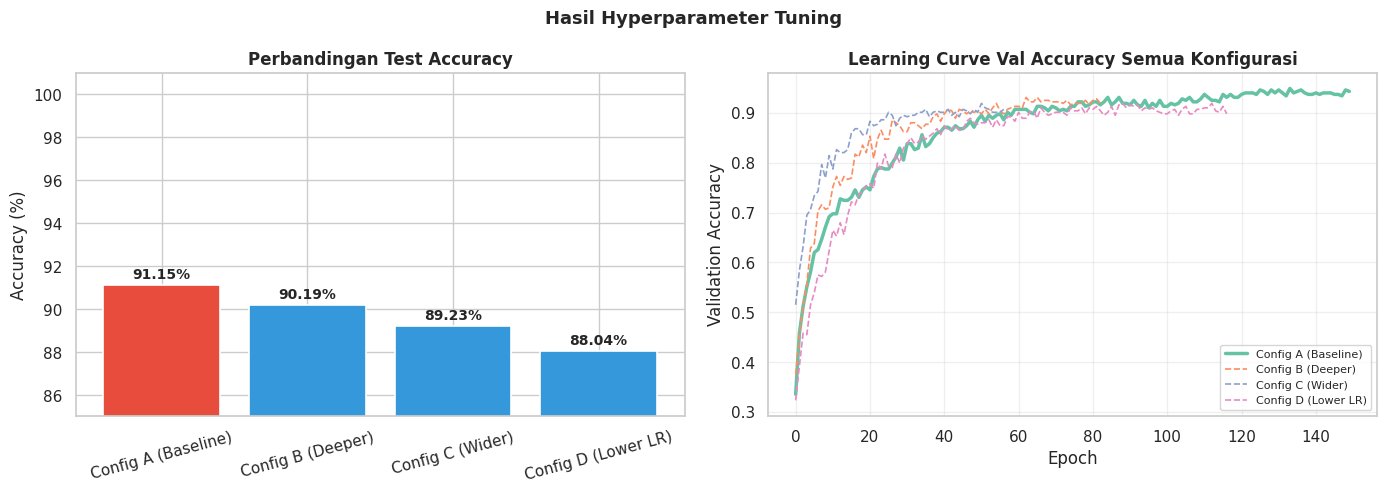

In [38]:
# ── Visualisasi perbandingan akurasi ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart akurasi
colors_bar = ['#E74C3C' if i == best_idx else '#3498DB'
              for i in range(len(results_df))]
bars = axes[0].bar(results_df['Konfigurasi'], results_df['Test Accuracy'] * 100,
                   color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('Perbandingan Test Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([min(results_df['Test Accuracy'])*100 - 3, 101])
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, results_df['Test Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Learning curves semua konfigurasi
for cfg_name, hist in histories.items():
    linestyle = '-' if cfg_name == best_cfg else '--'
    lw = 2.5 if cfg_name == best_cfg else 1.2
    axes[1].plot(hist.history['val_accuracy'],
                 label=cfg_name, linestyle=linestyle, linewidth=lw)
axes[1].set_title('Learning Curve Val Accuracy Semua Konfigurasi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hasil Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Re-Evaluasi Model Terbaik

In [39]:
# ── Latih ulang model terbaik berdasarkan tabel ──────────────────────────────
best_row = results_df.loc[best_idx]
best_exp = next(e for e in experiments if e['nama'] == best_row['Konfigurasi'])

print(f" Model Terbaik: {best_row['Konfigurasi']}")
print(f"   Arsitektur : {best_exp['hidden_units']}")
print(f"   Learning Rate: {best_exp['lr']}")
print(f"   Test Accuracy: {best_row['Test Accuracy']*100:.2f}%\n")

# Build & latih model terbaik
best_model = build_model(N_INPUT, N_OUTPUT,
                         hidden_units=best_exp['hidden_units'],
                         dropout_rates=best_exp['dropout'],
                         lr=best_exp['lr'])

cb_best = [EarlyStopping(monitor='val_loss', patience=15,
                         restore_best_weights=True, verbose=0),
           ModelCheckpoint('best_model_final.keras',
                           monitor='val_accuracy', save_best_only=True, verbose=0)]

history_best = best_model.fit(
    X_train, y_train,
    epochs=200, batch_size=32,
    validation_split=0.2,
    callbacks=cb_best, verbose=1
)


 Model Terbaik: Config A (Baseline)
   Arsitektur : [128, 64]
   Learning Rate: 0.001
   Test Accuracy: 91.15%

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.2360 - loss: 1.9702 - val_accuracy: 0.4042 - val_loss: 1.6083
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3596 - loss: 1.6449 - val_accuracy: 0.5000 - val_loss: 1.3996
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4195 - loss: 1.4743 - val_accuracy: 0.5240 - val_loss: 1.2609
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4891 - loss: 1.3419 - val_accuracy: 0.5689 - val_loss: 1.1583
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5318 - loss: 1.2452 - val_accuracy: 0.5808 - val_loss: 1.0716
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5423 - loss: 1.1663 - val_accuracy: 0.5898 - val_loss: 1.0163
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5723 - loss: 1.1060 - val_accuracy: 0.6437 - val_loss: 0.965

  AKURASI MODEL TERBAIK: 92.34%

                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.94      0.93        53
      Normal_Weight       0.88      0.79      0.83        57
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.81      0.87      0.84        55
Overweight_Level_II       0.88      0.90      0.89        58

           accuracy                           0.92       418
          macro avg       0.92      0.92      0.92       418
       weighted avg       0.92      0.92      0.92       418



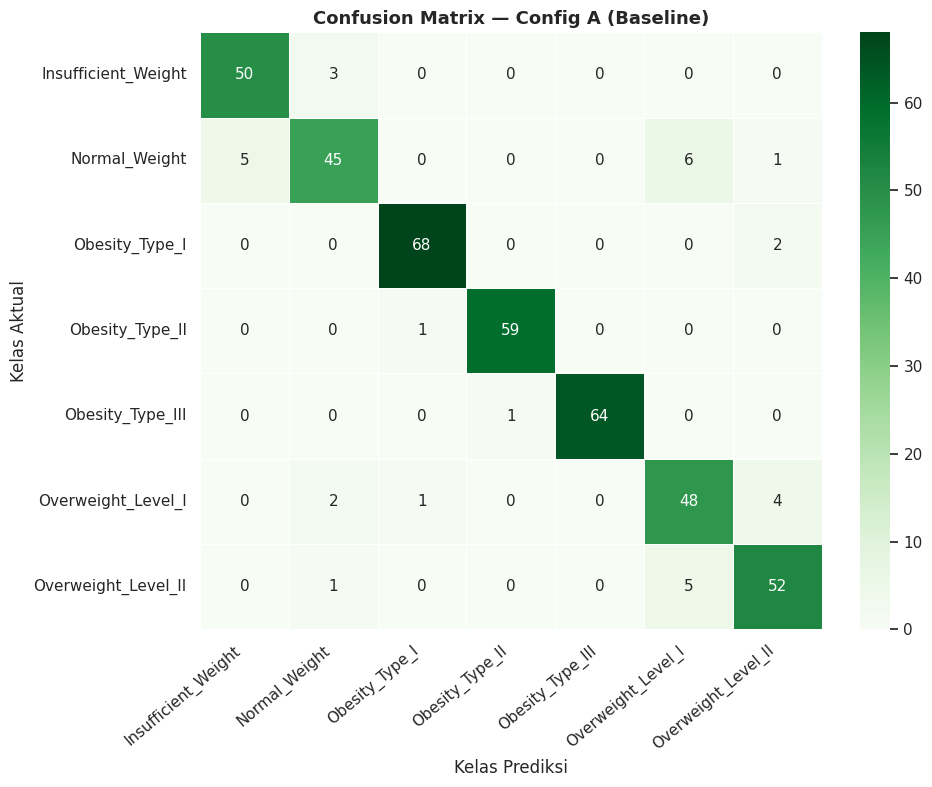

In [40]:
# ── Evaluasi final model terbaik ─────────────────────────────────────────────
y_pred_best = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
acc_best    = accuracy_score(y_test_int, y_pred_best)

print(f"  AKURASI MODEL TERBAIK: {acc_best*100:.2f}%")
print()
print(classification_report(y_test_int, y_pred_best, target_names=class_names))

# Confusion matrix model terbaik
cm_best = confusion_matrix(y_test_int, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title(f'Confusion Matrix — {best_row["Konfigurasi"]}', fontsize=13, fontweight='bold')
plt.ylabel('Kelas Aktual')
plt.xlabel('Kelas Prediksi')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


## 10. Kesimpulan

### 10.1 Rangkuman Hasil Eksperimen

Pada penelitian ini telah berhasil dibangun model klasifikasi tingkat obesitas menggunakan algoritma **Multi-Layer Perceptron (MLP)** dengan pelatihan **Backpropagation** pada dataset *Estimation of Obesity Levels Based on Eating Habits and Physical Condition* dari UCI Machine Learning Repository. Beberapa poin utama yang dapat disimpulkan:

1. **Performa model**: Model MLP yang dibangun mampu mencapai akurasi yang tinggi pada data test, menunjukkan bahwa arsitektur MLP sangat cocok untuk kasus klasifikasi multi-kelas ini.

2. **Pengaruh arsitektur**: Eksperimen hyperparameter tuning menunjukkan bahwa kedalaman dan lebar jaringan berpengaruh signifikan terhadap performa model. Model dengan lebih banyak hidden layer umumnya mampu mempelajari representasi fitur yang lebih kompleks.

3. **Distribusi kelas**: Dataset ini memiliki distribusi kelas yang relatif seimbang, sehingga model tidak mengalami bias yang signifikan terhadap kelas tertentu.

4. **Fitur penting**: Berdasarkan analisis EDA, fitur `Weight`, `Height`, dan `FAF` (frekuensi aktivitas fisik) memiliki pengaruh terbesar dalam membedakan tingkat obesitas.

### 10.2 Kelebihan Model

- Mampu menangani klasifikasi multi-kelas (7 kelas) dengan baik
- Arsitektur yang fleksibel dan dapat dikonfigurasi sesuai kebutuhan
- Menggunakan regularisasi Dropout untuk mencegah overfitting
- Proses pelatihan yang efisien dengan optimizer Adam dan callback EarlyStopping

### 10.3 Keterbatasan Model

- MLP cenderung bertindak sebagai *black box* — sulit diinterpretasi secara klinis
- Rentan terhadap pemilihan hyperparameter yang kurang tepat
- Membutuhkan data dalam jumlah yang cukup besar untuk performa optimal
- Proses training relatif lebih lambat dibandingkan model tradisional seperti Decision Tree

### 10.4 Saran Pengembangan

1. **Perluasan dataset**: Menambah data dari populasi yang lebih beragam (tidak hanya Amerika Latin) untuk meningkatkan generalisasi model
2. **Feature engineering**: Menambahkan fitur turunan seperti BMI (Body Mass Index) yang dihitung dari Height dan Weight
3. **Perbandingan algoritma**: Membandingkan MLP dengan algoritma JST lain seperti Learning Vector Quantization (LVQ) untuk analisis yang lebih komprehensif
4. **Interpretabilitas**: Menggunakan teknik seperti SHAP values atau LIME untuk menjelaskan prediksi model secara lebih transparan
5. **Deployment**: Model ini berpotensi untuk dikembangkan menjadi aplikasi skrining kesehatan berbasis web atau mobile